<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/Tranformer_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From LSTM to Attention: Why Transformers Became Necessary

---

## Opening Question

We solved many NLP problems using:

- TF-IDF
- RNN
- LSTM
- GRU

So a natural question arises:

> If LSTM was already powerful, why did the world move to Transformers?

Why did almost every major modern AI model shift toward Attention?

Examples:

- Google Translate improved dramatically
- BERT changed NLP
- GPT models became possible
- Multimodal AI emerged

Today we begin the answer.

---

## Historical Progression of NLP Models

### Phase 1: Static Representation

TF-IDF treated text as word importance counts.

Problem:

- No word order
- No context
- "dog bites man" = similar to "man bites dog"

---

### Phase 2: Sequential Models

RNN introduced memory.

Idea:

At each time step:

$$
h_t = f(x_t, h_{t-1})
$$

Now order matters.

---

### Phase 3: Better Memory

LSTM / GRU improved long-range learning using gates.

This solved many problems:

- Sentiment analysis
- Translation
- Sequence labeling
- Text generation

So why move further?

That is today's core topic.

---

## Quick Check

1. Why was TF-IDF limited for language understanding?

2. What problem did RNN solve?

3. Why was LSTM considered superior to vanilla RNN?

4. If LSTM was strong, what new limitation might still remain?

Next we ask:

Even if LSTM remembers better...

Is recurrence itself the real bottleneck?

# Why Recurrence Is Still a Bottleneck

---

## Recall LSTM Computation Style

For an LSTM (or RNN), sequence processing happens like:

$$
x_1 \rightarrow x_2 \rightarrow x_3 \rightarrow \cdots \rightarrow x_T
$$

At each step:

$$
h_t = f(x_t, h_{t-1})
$$

Meaning:

- Current state depends on previous state
- Token \(t\) cannot be processed before token \(t-1\)

This is called **recurrence**.

---

# Problem 1: Sequential Dependency

Suppose sentence has 100 words.

To compute hidden state for word 100:

You must compute:

- word 1
- then word 2
- then word 3
- ...
- then word 99
- then word 100

So computation is inherently step-by-step.

---

# Why This Is a Serious Issue

Modern hardware (GPU / TPU) is built for:

- matrix multiplication
- parallel operations
- many values together

But recurrent models force:

- one token at a time

This wastes parallel compute power.

---

# Problem 2: Long Information Path

Suppose token 1 influences token 50.

Then information must travel through chain:

$$
1 \rightarrow 2 \rightarrow 3 \rightarrow \cdots \rightarrow 50
$$

Even with LSTM gates, this path is still long.

Longer path means:

- harder optimization
- memory dilution
- slower learning of distant relations

---

# Problem 3: Hidden State Compression

At time step \(t\), hidden state \(h_t\) tries to summarize all past tokens.

That means one vector must represent:

- grammar
- subject
- sentiment
- names
- context
- negation
- dependencies

This is demanding.

---

# Key Insight

LSTM improved memory flow.

But it did **not remove the chain structure**.

So researchers asked:

> Why must token 50 wait for token 49?

> Why not let tokens interact directly?

This question leads to Attention.

---

## Quick Check

1. Why are RNN/LSTM difficult to parallelize?

2. Why does long-distance dependency remain hard even in LSTM?

3. What does hidden state compression mean?

4. Which is better for hardware:
   - sequential recurrence
   - matrix parallel computation

Even worse:

Many encoder-decoder systems compressed an entire sentence into one final vector.

Can one vector really store everything?

Next: Fixed-Length Context Limitation

# Fixed-Length Context Limitation

---

## Where This Problem Appeared Strongly

In early sequence-to-sequence translation models:

Input sentence:

$$
x_1, x_2, x_3, \dots, x_T
$$

Encoder RNN/LSTM reads full sentence and produces final hidden state:

$$
h_T
$$

Then decoder uses this single vector to generate translation.

So entire sentence meaning is compressed into:

$$
h_T
$$

---

# Central Question

Can one vector store:

- subject
- object
- tense
- negation
- names
- long dependencies
- emphasis
- phrase relations
- rare words

for long sentences?

Often: **No**

---

# Example 1: Long Sentence Translation

Input:

> The student who studied all night before the difficult exam finally passed confidently.

To translate final words correctly, decoder may need:

- subject = student
- event = studied
- result = passed
- modifier = confidently

But all must come through one summary vector.

---

# Example 2: Information Dilution

Imagine pouring 20 facts into one small bottle.

Some details survive.

Some details get blurred.

This happened in fixed-context encoder-decoder models.

---

# Mathematical View

Encoder creates:

$$
h_t = f(x_t, h_{t-1})
$$

Final state:

$$
c = h_T
$$

Decoder predicts:

$$
y_t = g(y_{t-1}, s_{t-1}, c)
$$

Same context vector \(c\) used repeatedly.

So every output token depends on the **same compressed summary**.

---

# Why This Is Restrictive

Different output words need different source information.

Example in translation:

When generating verb → need source verb.

When generating noun → need noun phrase.

When generating pronoun → need antecedent.

But one fixed vector gives same summary to all steps.

---

# Key Insight

Different decoding moments need access to different input positions.

So instead of one frozen summary:

> Let decoder dynamically look back at relevant tokens.

This becomes Attention.

---

## Quick Check

1. In old seq2seq models, what does the vector \(h_T\) represent?

2. Why does sentence length worsen this problem?

3. Why may different output tokens need different parts of the input?

4. What is better:
   - one fixed summary
   - dynamic access to source tokens

So the next breakthrough idea was simple but powerful:

Instead of remembering everything equally...

Focus selectively on what matters now.

Next: Selective Focus Intuition

# Selective Focus Intuition

---

## Human Analogy

When humans read a sentence, we do not give equal attention to every word.

Sentence:

> The movie was not good at all.

To detect sentiment, we naturally focus on:

- not
- good

Less focus on:

- the
- was
- at

This selective relevance is powerful.

---

# Old Model Behavior

Earlier recurrent systems tried to carry all useful information inside hidden states.

That means relevance was mixed internally.

But what if the model could explicitly ask:

> Which past words matter right now?

That is the birth of Attention.

---

# Core Idea of Attention

For current prediction step, assign importance to previous tokens.

Then use important tokens more strongly.

Instead of:

same memory for everything

Use:

dynamic task-dependent focus.

---

# Example 1: Pronoun Resolution

Sentence:

> Riya gave Neha her notebook because she trusted her.

To interpret "she", model should focus on relevant names.

Attention helps compare candidate words directly.

---

# Example 2: Negation

Sentence:

> The product is good but not durable.

For predicting sentiment of durability:

Need stronger focus on:

- not
- durable

Not on earlier word "good".

---

# Example 3: Translation

French output word generation may need specific English source word.

Instead of one summary vector:

decoder attends to relevant source token.

---

# Mathematical Intuition

Suppose past token vectors are:

$$
v_1, v_2, v_3, \dots, v_n
$$

Current step computes relevance scores:

$$
e_1, e_2, e_3, \dots, e_n
$$

Larger score = more relevant token.

Then model combines useful tokens more strongly.

(Exact normalization comes next section.)

---

# Key Insight

Attention does not erase old memory.

It adds a retrieval mechanism.

Instead of only storing information:

the model learns **where to look**.

---

## Quick Check

1. Why is equal treatment of all words inefficient?

2. In sentiment analysis, why is "not" often critical?

3. Attention is closer to:
   - storing everything in one vector
   - dynamically retrieving relevant parts

4. Give one NLP task where selective focus helps.

We now need one mathematical question:

How do we convert relevance scores into usable importance weights?

Next: Soft Alignment

# Soft Alignment Mechanism

---

## Hard Selection vs Soft Selection

Suppose model must focus on one relevant word.

### Hard Selection

Choose exactly one token:

- token 3 only
- ignore all others

Problem:

- non-smooth
- unstable learning
- difficult optimization

---

### Soft Selection

Give every token a weight:

- important tokens get larger weights
- less useful tokens get smaller weights

All tokens contribute, but unequally.

This is called **soft alignment**.

---

# Example Sentence

Sentence:

> The movie was not good

Suppose while predicting sentiment, relevance scores become:

| Token | Raw Score |
|------|-----------|
| The | 0.2 |
| movie | 0.4 |
| was | 0.1 |
| not | 2.0 |
| good | 1.8 |

Clearly:

- not
- good

should dominate.

---

# Convert Scores into Probabilities

Need weights that are:

1. Positive  
2. Comparable  
3. Sum to 1

We use softmax:

:contentReference[oaicite:0]{index=0}

Where:

- \(e_i\) = raw relevance score  
- \(\alpha_i\) = normalized attention weight

---

# Interpretation

If score is large:

$$
e^{e_i}
$$

becomes large.

So token receives higher weight.

If score is small or negative:

weight shrinks.

---

# Weighted Context Vector

If token representations are:

$$
v_1, v_2, \dots, v_n
$$

Then final context:

:contentReference[oaicite:1]{index=1}

So context is a weighted summary emphasizing relevant tokens.

---

# Why This Is Beautiful

Instead of manually selecting rules like:

- focus on negation
- focus on nouns
- focus on names

Model learns weights automatically from data.

---

# Key Insight

Soft alignment gives differentiable focus.

That means gradients can train attention smoothly.

This was crucial for deep learning success.

---

## Quick Check

1. Why is soft selection easier to train than hard selection?

2. Why must weights sum to 1?

3. If one token has much larger score, what happens after softmax?

4. Why can multiple words still matter in soft attention?

Now one deeper question remains:

Where do these relevance scores come from?

How does a token decide what it is searching for?

Next: Query–Key–Value Intuition

# Query–Key–Value Conceptual Framework

---

## The Central Question

In the previous section, we used relevance scores:

$$
e_1, e_2, \dots, e_n
$$

But where do these scores come from?

How does the model know:

- what to search for?
- which token matches?
- what information to extract?

This is solved using:

- Query
- Key
- Value

---

# Real-Life Search Engine Analogy

Imagine searching a library.

### Query

What you are looking for.

Example:

> "books on deep learning"

### Key

Labels/index metadata of each book.

### Value

Actual content inside the book.

Search compares:

Query vs Key

Then retrieves:

Value

---

# NLP Interpretation

For each token representation \(x_i\), model creates three learned views:

- Query = what this token wants
- Key = what this token offers for matching
- Value = information this token carries

---

# Example Sentence

Sentence:

> The animal didn't cross the road because it was tired.

Suppose model processes token:

> it

Then query may ask:

- Which previous noun matches singular object?
- Which entity can be tired?

Earlier tokens like:

- animal
- road

provide keys.

Matching may favor:

- animal

Then corresponding value from "animal" contributes strongly.

---

# Why Three Separate Roles?

One vector doing everything is restrictive.

Separate projections allow:

- search behavior (Query)
- match identity (Key)
- content transfer (Value)

This increases flexibility.

---

# Conceptual Pipeline

For current token:

1. Build Query  
2. Compare with all Keys  
3. Produce attention weights  
4. Use weights on Values  
5. Get context output

---

# Mathematical Preview

In next lecture we formalize:

:contentReference[oaicite:0]{index=0}

For now, keep intuition only:

Same token embedding is transformed into three useful roles.

---

# Key Insight

Attention is not random lookup.

It is learned similarity-based retrieval.

---

## Quick Check

1. Query represents what?

2. Key is used for what?

3. Value contains what?

4. Why not use one single vector for all three roles?

5. In pronoun resolution, which earlier token's key may match the pronoun query?

Now let us see this mechanism working on real language examples.

How does attention help sentences directly?

Next: Attention Through Sentence Examples

# Attention Mechanism Through Sentence Examples

---

## Why Examples Matter

Attention sounds abstract until we observe:

> Which words should look at which other words?

Language is full of hidden relationships.

Attention helps expose them.

---

# Example 1: Pronoun Resolution

Sentence:

> Rahul gave Aman his laptop because he trusted him.

When processing token:

> he

Model may attend strongly to:

- Rahul
- Aman

to infer likely reference.

When processing:

> his

Model may attend to noun ownership candidates.

---

# Example 2: Negation Understanding

Sentence:

> The movie was not interesting.

When predicting sentiment of:

> interesting

Attention should emphasize:

- not
- interesting

Because meaning changes through interaction.

Without attending to "not", sentiment may be wrong.

---

# Example 3: Long-Distance Dependency

Sentence:

> The bouquet of roses on the table near the window smells fresh.

Verb:

> smells

must relate to subject:

> bouquet

not nearby nouns:

- roses
- table
- window

Attention can directly connect:

smells ↔ bouquet

even across distance.

---

# Example 4: Translation Alignment

English:

> I drink water

French generation of:

> eau

should attend to:

> water

Different output words attend to different source words.

---

# Example 5: Question Answering

Context:

> Newton developed laws of motion.

Question:

> Who developed laws of motion?

Attention in model focuses on:

- Newton
- developed
- laws of motion

and suppresses irrelevant tokens.

---

# Matrix View Intuition

Suppose 5-token sentence.

Attention may create matrix:

| Query Token | Strong Focus On |
|------------|-----------------|
| he | Rahul / Aman |
| interesting | not |
| smells | bouquet |
| eau | water |

Each token can have different focus pattern.

---

# Key Insight

Meaning in language often depends on relationships between words, not isolated words.

Attention learns these relationships dynamically.

---

# Coding Demo: From Raw Scores to Attention Weights

In attention, the model first produces raw relevance scores.

These scores answer:

> How relevant is each token for the current prediction?

But raw scores are not directly usable because:

- they may be negative
- they may not be comparable
- they do not sum to 1

So we convert them into attention weights using softmax.

The attention weights behave like an importance distribution over tokens.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Create a Toy Sentence

Let us take a simple sentence:

"The movie was not good"

Suppose the model is trying to understand the sentiment.

Intuitively, the most important words are:

- not
- good

So we manually assign higher raw relevance scores to these words.

In [ ]:
tokens = ["The", "movie", "was", "not", "good"]

# Raw relevance scores manually chosen for intuition
raw_scores = np.array([0.2, 0.5, 0.1, 2.0, 1.8])

print("Tokens:", tokens)
print("Raw relevance scores:", raw_scores)

Tokens: ['The', 'movie', 'was', 'not', 'good']
Raw relevance scores: [0.2 0.5 0.1 2.  1.8]


## Step 2: Define Softmax Function

Softmax converts raw scores into positive weights that sum to 1.

Mathematically:

$$
\alpha_i = \frac{e^{e_i}}{\sum_{j=1}^{n} e^{e_j}}
$$

Where:

- $e_i$ is the raw relevance score of token $i$
- $\alpha_i$ is the attention weight of token $i$

In [ ]:
def softmax(scores):
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores)

attention_weights = softmax(raw_scores)

print("Attention weights:", attention_weights)
print("Sum of attention weights:", attention_weights.sum())

Attention weights: [0.07013913 0.09467793 0.06346451 0.42431703 0.3474014 ]
Sum of attention weights: 1.0


## Step 3: Visualize Raw Scores vs Attention Weights

Now we compare:

- raw relevance scores
- normalized attention weights

The attention weights are easier to interpret because they behave like probabilities.

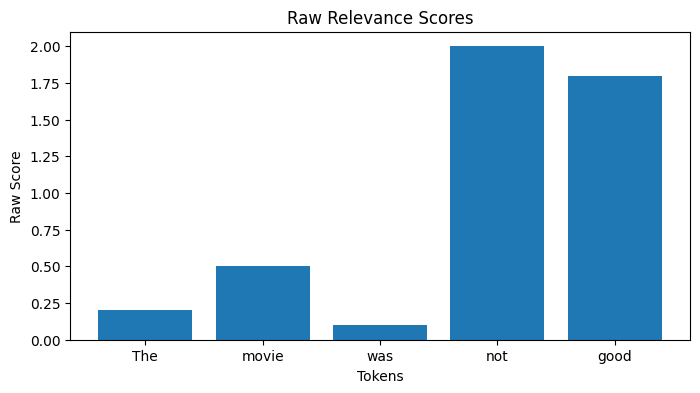

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(tokens, raw_scores)
plt.title("Raw Relevance Scores")
plt.xlabel("Tokens")
plt.ylabel("Raw Score")
plt.show()

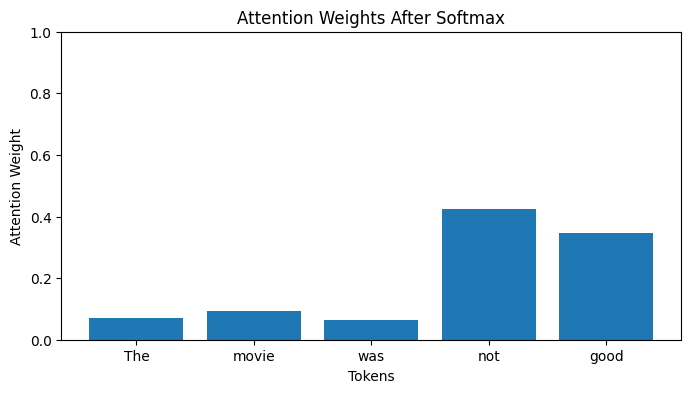

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(tokens, attention_weights)
plt.title("Attention Weights After Softmax")
plt.xlabel("Tokens")
plt.ylabel("Attention Weight")
plt.ylim(0, 1)
plt.show()

## Interpretation

Observe that:

- "not" receives a high attention weight
- "good" also receives a high attention weight
- less important words receive smaller weights
- all attention weights sum to 1

So attention creates a soft importance distribution over tokens.

This is why attention is not simply selecting one word.

It softly combines information from all words, but gives more importance to relevant ones.

In [ ]:
for token, score, weight in zip(tokens, raw_scores, attention_weights):
    print(f"{token:>6} | Raw Score: {score:.2f} | Attention Weight: {weight:.4f}")

   The | Raw Score: 0.20 | Attention Weight: 0.0708
 movie | Raw Score: 0.40 | Attention Weight: 0.0864
   was | Raw Score: 0.10 | Attention Weight: 0.0640
   not | Raw Score: 2.00 | Attention Weight: 0.4282
  good | Raw Score: 1.80 | Attention Weight: 0.3506


Notice what happened here.

The model did not completely ignore "The", "movie", or "was".

But their contribution became small.

The words "not" and "good" dominate the final meaning.

This is exactly what we want in sentiment analysis.

The sentence:

"The movie was good"

and

"The movie was not good"

contain similar words, but their meaning changes because of attention to "not".

Softmax does not create intelligence by itself.

Softmax only converts scores into weights.

The real learning happens in how the model generates those scores.

In today's lecture, we manually assigned scores.

In the Transformer, these scores come from Query-Key similarity.

That will be studied mathematically in the next lecture.

## Concept Check

1. Why do we need softmax after raw relevance scores?

2. Why should attention weights sum to 1?

3. In this example, why did "not" receive high attention?

4. If the raw score of "movie" is increased, what will happen to its attention weight?

5. Does softmax decide relevance by itself, or does it only normalize scores?

Now we know how attention weights are formed.

Next question:

Once we have these weights, how do we combine token information?

This leads to the weighted context vector.

## Mathematical Idea

Suppose token vectors are:

$$
v_1, v_2, v_3, \dots, v_n
$$

and attention weights are:

$$
\alpha_1, \alpha_2, \alpha_3, \dots, \alpha_n
$$

Then the context vector is:

$$
c = \sum_{i=1}^{n} \alpha_i v_i
$$

Meaning:

- important token vectors contribute more
- less important token vectors contribute less
- final context is a weighted combination of all token vectors

## Step 1: Use the Same Sentence

We will continue with:

"The movie was not good"

Previously, we assumed the raw relevance scores were higher for:

- not
- good

In [ ]:
tokens = ["The", "movie", "was", "not", "good"]

raw_scores = np.array([0.2, 0.4, 0.1, 2.0, 1.8])

def softmax(scores):
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores)

attention_weights = softmax(raw_scores)

print("Tokens:", tokens)
print("Attention weights:", attention_weights)
print("Sum:", attention_weights.sum())

Tokens: ['The', 'movie', 'was', 'not', 'good']
Attention weights: [0.07077682 0.086447   0.06404151 0.4281748  0.35055987]
Sum: 1.0


## Step 2: Create Toy Token Vectors

In real models, every token has an embedding vector.

For teaching purpose, we will create small 2-dimensional vectors.

Let each vector roughly represent two hidden features:

- Feature 1: positive meaning
- Feature 2: negative/negation meaning

This is not how real embeddings are directly interpreted, but it is useful for classroom intuition.

In [ ]:
# Toy token vectors with 2 hidden dimensions
# Dimension 1: positive-like signal
# Dimension 2: negation/negative-like signal

value_vectors = np.array([
    [0.1, 0.0],   # The
    [0.2, 0.1],   # movie
    [0.1, 0.0],   # was
    [0.0, 1.0],   # not
    [1.0, 0.1]    # good
])

print("Value vectors shape:", value_vectors.shape)
print(value_vectors)

Value vectors shape: (5, 2)
[[0.1 0. ]
 [0.2 0.1]
 [0.1 0. ]
 [0.  1. ]
 [1.  0.1]]


## Step 3: Multiply Each Token Vector by Its Attention Weight

Each token vector is scaled by its attention weight.

High attention weight means stronger contribution.

Low attention weight means weaker contribution.

In [ ]:
weighted_vectors = attention_weights.reshape(-1, 1) * value_vectors

print("Weighted vectors shape:", weighted_vectors.shape)

for token, weight, vec, weighted_vec in zip(tokens, attention_weights, value_vectors, weighted_vectors):
    print(f"{token:>6} | weight = {weight:.4f} | vector = {vec} | weighted vector = {weighted_vec}")

Weighted vectors shape: (5, 2)
   The | weight = 0.0708 | vector = [0.1 0. ] | weighted vector = [0.00707768 0.        ]
 movie | weight = 0.0864 | vector = [0.2 0.1] | weighted vector = [0.0172894 0.0086447]
   was | weight = 0.0640 | vector = [0.1 0. ] | weighted vector = [0.00640415 0.        ]
   not | weight = 0.4282 | vector = [0. 1.] | weighted vector = [0.        0.4281748]
  good | weight = 0.3506 | vector = [1.  0.1] | weighted vector = [0.35055987 0.03505599]


## Step 4: Add Weighted Vectors to Get Context Vector

The context vector is the sum of all weighted token vectors.

In [ ]:
context_vector = weighted_vectors.sum(axis=0)

print("Context vector:", context_vector)
print("Context vector shape:", context_vector.shape)

Context vector: [0.38133111 0.47187548]
Context vector shape: (2,)


## Step 5: Visualize Token Contributions

Each token contributes differently to the final context vector.

Because "not" and "good" have high attention weights, they dominate the context.

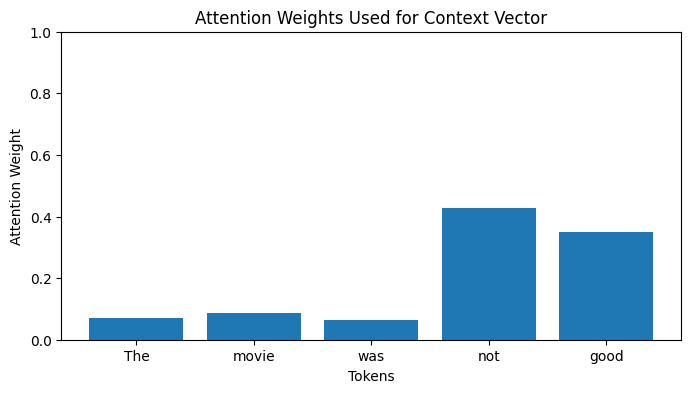

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(tokens, attention_weights)
plt.title("Attention Weights Used for Context Vector")
plt.xlabel("Tokens")
plt.ylabel("Attention Weight")
plt.ylim(0, 1)
plt.show()

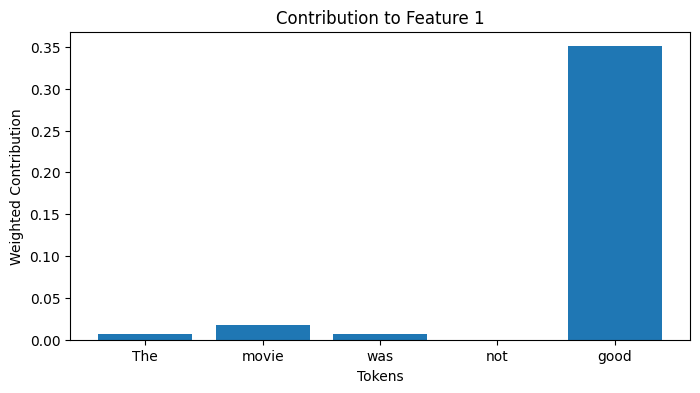

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(tokens, weighted_vectors[:, 0])
plt.title("Contribution to Feature 1")
plt.xlabel("Tokens")
plt.ylabel("Weighted Contribution")
plt.show()

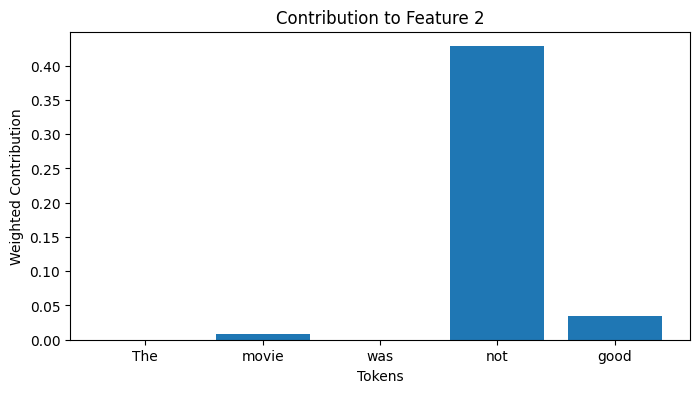

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(tokens, weighted_vectors[:, 1])
plt.title("Contribution to Feature 2")
plt.xlabel("Tokens")
plt.ylabel("Weighted Contribution")
plt.show()

## Interpretation

The final context vector summarizes the sentence for the current prediction.

But unlike a simple average, it is not treating every token equally.

It is shaped mostly by the most relevant tokens.

In this case:

- "not" contributes strongly to the negation-like feature
- "good" contributes strongly to the positive-like feature

Together they help the model understand the phrase:

"not good"

## Important Point

Attention is a weighted average mechanism.

But it is a learned weighted average.

In this toy example, we manually created the weights.

In an actual attention layer:

- token vectors are learned
- relevance scores are computed from Query-Key similarity
- attention weights are produced by softmax
- final context is computed from Value vectors

In [ ]:
print("Final Summary")
print("-" * 40)
for token, weight in zip(tokens, attention_weights):
    print(f"{token:>6} contributes {weight*100:.2f}% importance")

print("-" * 40)
print("Final context vector:", context_vector)

Final Summary
----------------------------------------
   The contributes 7.08% importance
 movie contributes 8.64% importance
   was contributes 6.40% importance
   not contributes 42.82% importance
  good contributes 35.06% importance
----------------------------------------
Final context vector: [0.38133111 0.47187548]


The main idea is:

Attention creates a customized summary.

This summary is not fixed for all tasks.

For sentiment, the model may focus on "not" and "good".

For topic classification, it may focus more on "movie".

For translation, it may focus on a different source word at every output step.

So attention is dynamic, context-dependent, and learnable.

## Concept Check

1. What is a context vector?

2. Why is the context vector not a simple average?

3. What happens if a token has a very small attention weight?

4. In the phrase "not good", why should both words contribute?

5. In real Transformer attention, are the value vectors manually created?

Now you have seen two things:

1. how attention weights are formed
2. how those weights create a context vector

Next, we return to the main lecture flow and introduce the Transformer big picture.

But before that, we can optionally show one heatmap-style demo of token-to-token attention.

This will prepare students for self-attention.

# Coding Demo: Tiny Sentence Attention Heatmap

So far, we have seen that attention assigns importance weights.

But in self-attention, every token can attend to every other token.

That means we can create a token-to-token attention matrix.

Each row asks:

> For this token, which other tokens are important?

Each column answers:

> How much is this token being attended to?

Today we will use a manually designed attention matrix only for intuition.

In the next lectures, we will compute this matrix using Query, Key, and Value.

In [ ]:
#Step=1
tokens = ["The", "movie", "was", "not", "good"]
n = len(tokens)

print("Tokens:", tokens)
print("Number of tokens:", n)

Tokens: ['The', 'movie', 'was', 'not', 'good']
Number of tokens: 5


## Step 2: Create a Toy Attention Matrix

Rows represent the token that is asking/querying.

Columns represent the token being attended to.

For example:

- row "good" shows which words "good" attends to
- row "not" shows which words "not" attends to

We manually design the matrix so that:

- "good" strongly attends to "not"
- "not" strongly attends to "good"
- "movie" attends more to itself and nearby words

In [ ]:
# Manually created attention weights for teaching intuition
# Each row should sum to 1

attention_matrix = np.array([
    [0.60, 0.20, 0.10, 0.05, 0.05],  # The
    [0.10, 0.55, 0.15, 0.10, 0.10],  # movie
    [0.10, 0.20, 0.45, 0.15, 0.10],  # was
    [0.05, 0.05, 0.10, 0.30, 0.50],  # not
    [0.05, 0.05, 0.10, 0.55, 0.25]   # good
])

print("Attention matrix shape:", attention_matrix.shape)
print("Row sums:", attention_matrix.sum(axis=1))

Attention matrix shape: (5, 5)
Row sums: [1. 1. 1. 1. 1.]


## Step 3: Visualize the Attention Matrix

A heatmap makes attention easier to interpret.

Lighter or stronger cells indicate stronger attention.

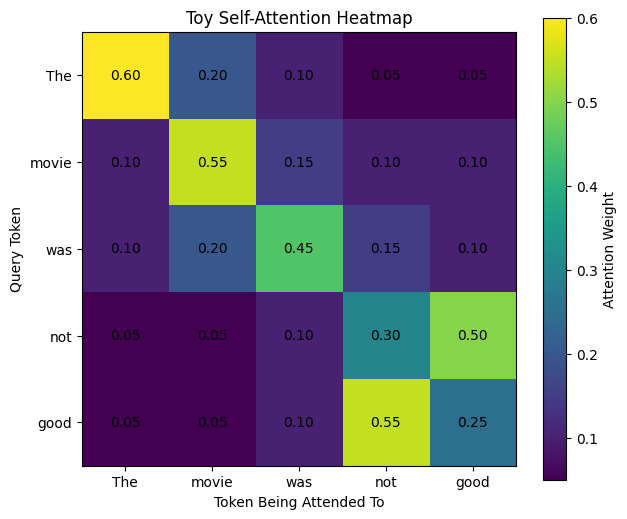

In [ ]:
plt.figure(figsize=(7, 6))

plt.imshow(attention_matrix)

plt.xticks(range(n), tokens)
plt.yticks(range(n), tokens)

plt.xlabel("Token Being Attended To")
plt.ylabel("Query Token")
plt.title("Toy Self-Attention Heatmap")

plt.colorbar(label="Attention Weight")

for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{attention_matrix[i, j]:.2f}",
                 ha="center", va="center")

plt.show()

## How to Read This Heatmap

Look at the row for:

"good"

This row tells us:

> When the model processes "good", which tokens influence it?

In this example, "good" attends strongly to:

- not
- good

This helps the model understand that the phrase is not simply positive.

It is modified by negation.

Now look at the row for:

"not"

It also attends strongly to:

- good

This shows a two-way relationship between negation and adjective.

In [ ]:
query_token = "good"
query_index = tokens.index(query_token)

print(f"Attention distribution for token: {query_token}")
print("-" * 45)

for token, weight in zip(tokens, attention_matrix[query_index]):
    print(f"{query_token:>6} attends to {token:>6} with weight {weight:.2f}")

Attention distribution for token: good
---------------------------------------------
  good attends to    The with weight 0.05
  good attends to  movie with weight 0.05
  good attends to    was with weight 0.10
  good attends to    not with weight 0.55
  good attends to   good with weight 0.25


## Step 4: Compare with Equal Attention

If every token receives equal attention, the model has no selective focus.

For 5 tokens, equal attention means each token gets:

$$
\frac{1}{5} = 0.20
$$

Let us compare equal attention with our toy attention distribution for the token "good".

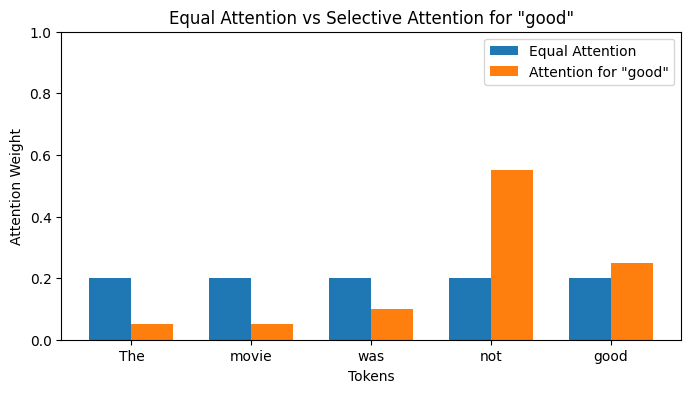

In [ ]:
equal_attention = np.ones(n) / n
good_attention = attention_matrix[query_index]

x = np.arange(n)
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, equal_attention, width, label="Equal Attention")
plt.bar(x + width/2, good_attention, width, label='Attention for "good"')

plt.xticks(x, tokens)
plt.ylim(0, 1)
plt.xlabel("Tokens")
plt.ylabel("Attention Weight")
plt.title('Equal Attention vs Selective Attention for "good"')
plt.legend()
plt.show()

## Interpretation

Equal attention treats every word as equally important.

Selective attention changes the representation of "good" by strongly considering "not".

This is the central power of attention:

> meaning is updated by looking at relevant tokens.

The token "good" alone may suggest positive sentiment.

But "good" attending to "not" helps the model move toward negative sentiment.

## Important Clarification

This attention matrix was manually created.

In real self-attention, the model does not manually decide these values.

Instead, it learns token representations and computes attention scores using:

$$
QK^T
$$

Then softmax converts those scores into attention weights.

That full mathematical process will be developed in the next lecture.

## Concept Check

1. In an attention matrix, what does each row represent?

2. What does each column represent?

3. Why should each row sum to 1?

4. In the phrase "not good", why should "good" attend to "not"?

5. Is the heatmap shown here manually created or learned by the model?

# Conceptual Analysis: "Attention Is All You Need"

Now that we have understood attention through examples and visualization, we are ready to discuss one of the most influential papers in modern AI:

**"Attention Is All You Need"**

This paper was published in 2017 by Vaswani et al.

The paper introduced the **Transformer architecture**.

Its core claim was bold:

> We can build a powerful sequence model using attention alone, without recurrence and without convolution.

This was a major shift in deep learning.

## Why Was This Paper So Important?

Before Transformers, most strong sequence models were based on:

- RNN
- LSTM
- GRU
- CNN-based sequence models
- encoder-decoder architectures with attention

Attention existed before the Transformer.

But the revolutionary idea was:

> Attention should not just support the model.
> Attention can become the model.

This is the key conceptual leap.

## Before the Transformer

Earlier models usually worked like this:

### Recurrent backbone

The model reads tokens one by one:

$$
x_1 \rightarrow x_2 \rightarrow x_3 \rightarrow \cdots \rightarrow x_T
$$

The hidden state carries memory forward:

$$
h_t = f(x_t, h_{t-1})
$$

Attention may be added later to help the decoder look back at encoder states.

So attention was helpful, but recurrence was still the backbone.

## What the Paper Changed

The Transformer asked:

> Why should sequence modeling be forced to happen step by step?

Instead of using recurrence, it allowed tokens to interact directly using self-attention.

So every token can look at every other token.

For a sentence with \(n\) tokens, self-attention builds an \(n \times n\) interaction structure.

This gives direct communication between distant words.

Example:

"The bouquet of roses near the window smells fresh."

The word "smells" can directly attend to "bouquet".

It does not need the information to travel through every intermediate word.

## The Main Architectural Shift

The paper shifted NLP from:

### Sequential memory-based processing

$$
h_t = f(x_t, h_{t-1})
$$

to:

### Matrix-based interaction processing

$$
\text{Token}_i \leftrightarrow \text{Token}_j
$$

for many pairs of tokens in parallel.

This made the architecture much more suitable for GPU/TPU computation.

## Why the Title Is So Powerful

The title says:

"Attention Is All You Need"

Meaning:

The authors were not saying that softmax alone is enough.

They were saying:

> A sequence model does not necessarily need recurrence or convolution as its main structure.

Attention can perform the core sequence interaction.

This was surprising because, for years, sequence meant recurrence.

Language was assumed to require step-by-step processing.

The Transformer challenged that assumption.

## What Students Should Not Misunderstand

The paper does **not** mean:

- attention alone as one formula solves everything
- positional information is unnecessary
- feed-forward layers are unnecessary
- normalization and residual connections are unnecessary

The Transformer still uses:

- embeddings
- positional encoding
- multi-head attention
- feed-forward networks
- residual connections
- layer normalization

So the better interpretation is:

> Recurrence is not necessary as the central engine of sequence modeling.

## Why This Was Good for Scaling

Transformers scaled well because:

1. Tokens can interact directly.
2. Computation is mostly matrix multiplication.
3. Training can be parallelized across sequence positions.
4. Long-range dependencies have shorter interaction paths.
5. The architecture can be stacked deeply using residual connections and normalization.

This made Transformers highly compatible with modern hardware.

## Important Historical Point

The Transformer was originally evaluated heavily on machine translation.

But its real impact became much larger.

The same architectural idea later became the foundation for:

- BERT-style encoder models
- GPT-style decoder models
- modern large language models
- many vision transformers
- multimodal AI systems

So this paper was not just an NLP paper.

It became a general-purpose deep learning architecture idea.

## Classroom Summary

The paper's contribution can be summarized in one sentence:

> It replaced sequential recurrence with parallel attention-based token interaction.

This is why the Transformer became necessary after LSTM/GRU.

LSTM improved memory.

Transformer redesigned the computation itself.

# Optional Visualization: RNN Chain vs Attention Interaction

Let us visually compare two computation styles:

1. RNN/LSTM style: each token mainly connects to the next token.
2. Attention style: each token can connect to every other token.

This is not a model implementation.

It is a structural visualization.

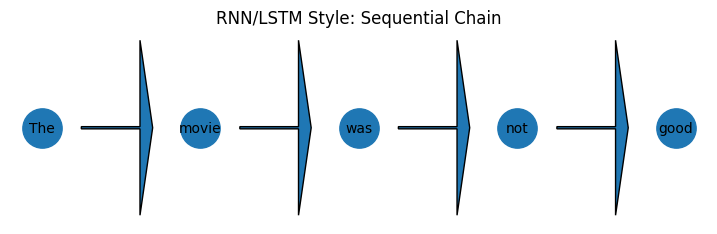

In [ ]:
tokens = ["The", "movie", "was", "not", "good"]
x = np.arange(len(tokens))
y = np.zeros(len(tokens))

plt.figure(figsize=(9, 2.5))

# Plot tokens
plt.scatter(x, y, s=800)

for i, token in enumerate(tokens):
    plt.text(x[i], y[i], token, ha="center", va="center")

# RNN chain arrows
for i in range(len(tokens) - 1):
    plt.arrow(x[i] + 0.25, y[i], 0.45, 0,
              head_width=0.08, head_length=0.08,
              length_includes_head=True)

plt.title("RNN/LSTM Style: Sequential Chain")
plt.axis("off")
plt.show()

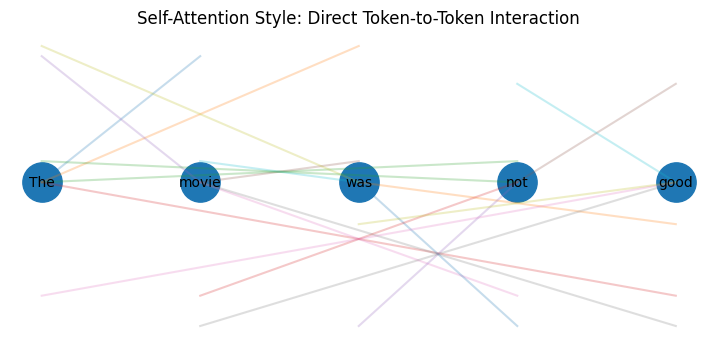

In [ ]:
tokens = ["The", "movie", "was", "not", "good"]
x = np.arange(len(tokens))
y = np.zeros(len(tokens))

plt.figure(figsize=(9, 4))

# Plot tokens
plt.scatter(x, y, s=800)

for i, token in enumerate(tokens):
    plt.text(x[i], y[i], token, ha="center", va="center")

# Attention all-to-all connections
for i in range(len(tokens)):
    for j in range(len(tokens)):
        if i != j:
            plt.plot([x[i], x[j]], [y[i], y[j] + 0.15 * np.sin(i + j)],
                     alpha=0.25)

plt.title("Self-Attention Style: Direct Token-to-Token Interaction")
plt.axis("off")
plt.show()

## Interpretation

In recurrent models, information moves through a chain.

In self-attention, tokens can directly exchange information.

This does not automatically mean attention is always better for every task.

But for large-scale language modeling, this structure made training and scaling dramatically more effective.

## Concept Check

1. Did attention exist before the Transformer?

2. What was the bold claim of "Attention Is All You Need"?

3. Why was removing recurrence important?

4. Why are Transformers more suitable for GPU/TPU training?

5. Does the Transformer use only one attention formula, or does it also need other components?

Now we are ready to look at the Transformer as an architecture.

We have already understood the core idea:

Attention allows direct selective interaction.

The Transformer takes this idea and builds the entire model around it.

# Transformer Big Picture

We have now understood the motivation:

- RNN processes tokens sequentially
- LSTM improves memory but still keeps recurrence
- Attention allows selective focus
- Self-attention allows tokens to directly interact with each other

Now we ask:

> How is a complete model built using attention?

That model is called the Transformer.

## The Big Idea

A Transformer is a neural network architecture built around attention.

Instead of processing a sentence as a time chain:

$$
x_1 \rightarrow x_2 \rightarrow x_3 \rightarrow \cdots \rightarrow x_T
$$

it processes the sequence more like a set of interacting tokens:

$$
x_i \leftrightarrow x_j
$$

where each token can exchange information with other tokens.

This is why Transformers are powerful for language.

Language meaning often depends on relationships between words.

## Transformer at a High Level

A Transformer usually contains:

1. Input embeddings  
2. Positional information  
3. Self-attention layers  
4. Feed-forward layers  
5. Residual connections  
6. Layer normalization  
7. Output prediction layer  

Today we only understand the big picture.

The mathematical details will come in the next lecture.

## Why Embeddings Are Needed

The model cannot directly process words as text.

Words are first converted into vectors.

Example:

$$
\text{"movie"} \rightarrow x_{\text{movie}} \in \mathbb{R}^{d}
$$

Each token becomes a vector representation.

So a sentence becomes a matrix:

$$
X \in \mathbb{R}^{n \times d}
$$

where:

- $n$ = number of tokens
- $d$ = embedding dimension

## Why Positional Information Is Needed

Self-attention compares tokens with each other.

But pure attention does not automatically know word order.

For example:

> dog bites man

and

> man bites dog

contain the same words.

But the meaning is different because order matters.

So Transformer must inject position information explicitly.

This is done using positional encoding or learned positional embeddings.

## What Self-Attention Does

Self-attention updates each token by allowing it to look at other tokens.

Example sentence:

> The movie was not good

When updating the representation of "good", the model may strongly consider:

- "not"
- "good"

So the new representation of "good" is context-aware.

It no longer means only "good" in isolation.

It means "good" in the context of "not good".

## What Feed-Forward Layers Do

After attention, each token has gathered information from other tokens.

Then a feed-forward network transforms each token representation.

A useful distinction is:

> Attention = communication across tokens

> Feed-forward network = transformation within each token

So the Transformer alternates between:

1. letting tokens communicate
2. refining each token representation

## Why Residual Connections and Normalization Are Needed

Deep networks are hard to train.

Transformers stack many layers.

To make deep stacking stable, they use:

- residual connections
- layer normalization

Residual connections help information and gradients flow through the network.

Layer normalization stabilizes the scale of activations.

We will study these in more detail in the next lecture.

# Coding Visualization: Transformer Block Flow

Let us draw a simple high-level Transformer block.

The goal is to see the flow:

Input Tokens  
→ Embeddings  
→ Positional Information  
→ Self-Attention  
→ Feed-Forward Network  
→ Contextual Representations

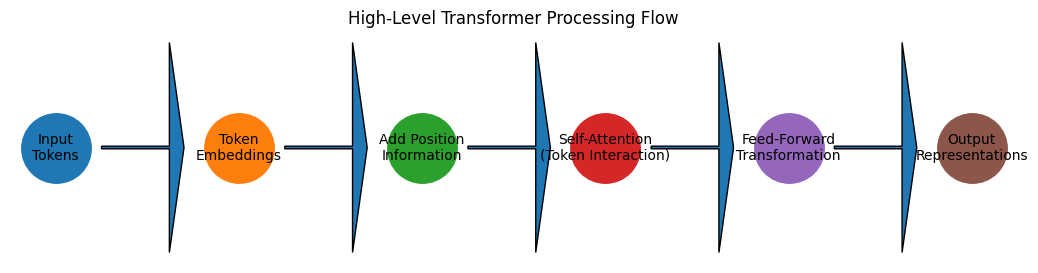

In [ ]:
import matplotlib.pyplot as plt

steps = [
    "Input\nTokens",
    "Token\nEmbeddings",
    "Add Position\nInformation",
    "Self-Attention\n(Token Interaction)",
    "Feed-Forward\nTransformation",
    "Output\nRepresentations"
]

x = list(range(len(steps)))
y = [0] * len(steps)

plt.figure(figsize=(13, 3))

for i, step in enumerate(steps):
    plt.scatter(x[i], y[i], s=2500)
    plt.text(x[i], y[i], step, ha="center", va="center", fontsize=10)

for i in range(len(steps) - 1):
    plt.arrow(x[i] + 0.25, y[i], 0.45, 0,
              head_width=0.08, head_length=0.08,
              length_includes_head=True)

plt.title("High-Level Transformer Processing Flow")
plt.axis("off")
plt.show()

## Interpretation of the Flow

The Transformer does not simply remember previous words.

It repeatedly updates token representations.

After several layers:

- each token becomes aware of relevant surrounding tokens
- long-range relationships can be captured
- sentence meaning becomes distributed across contextual token vectors

This is why Transformer embeddings are context-sensitive.

The word "bank" will have different representations in:

> river bank

and

> bank account

In a Transformer, the representation of "bank" is updated by attending to surrounding tokens.

In:

> river bank

the word "bank" may attend strongly to "river".

In:

> bank account

the word "bank" may attend strongly to "account".

So the same word can receive different contextual meaning.

## Concept Check

1. What is the central mechanism inside a Transformer?

2. Why does a Transformer need positional information?

3. What is the difference between attention and feed-forward layers?

4. Why are residual connections useful?

5. Why is the word "bank" a good example for contextual representation?

Now we understand the big picture.

But there are different Transformer structures.

Some models use an encoder.

Some use a decoder.

Some use both.

Next, we study the encoder-decoder idea.